<a href="https://colab.research.google.com/github/Yanina2105/MD-Lab05_FT/blob/develop/Laboratorio_N%C2%BA_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SEMANA 5: MODELOS DE APRENDIZAJE AUTOMÁTICO. MODELOS DE APRENDIZAJE PROFUNDO**

Con base a datos de cáncer de mama alojados en el repositorio UCI Machine Learning Repository
(https://archive.ics.uci.edu/ml/datasets/breast+cancer+wisconsin+%28original%29) y utilizando
las librerías de Python que se indican, haga lo siguiente:

Integrantes:

*   HUAMAN QUISPE, ABRAHAM SEBASTIAN JONATHAN
*   MINAYA TORRES, TERRY AGUSTIN
*   TRUJILLO TELLO, FIORELLA YANINA






In [27]:
import pandas as pd
import numpy as np

In [28]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data'
columnas = ['Sample_code_number', 'Clump_thickness', 'Uniformity_of_cell_size', 'Uniformity_of_cell_shape', 'Marginal_adhesion',
            'Single_epithelial_cell_size', 'Bare_nuclei', 'Bland_chromatin', 'Normal_nucleoli', 'Mitoses', 'Class']
df = pd.read_csv(url, names=columnas)
df.head()

,Sample_code_number,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


## **a. Por medio de la librería ‘Pandas’, lea la base de datos, separe las variables numéricas de las no numéricas tomando en cuenta la información que se encuentra en el repositorio, calcule sus estadísticos descriptivos y halle la matriz de correlación.**

In [29]:
# Tipo de datos
df.dtypes

,0
Sample_code_number,int64
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,object
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64


In [30]:
# Convertir la columna a numérico
df['Bare_nuclei'] = pd.to_numeric(df['Bare_nuclei'], errors='coerce')

# Ver cuántos valores faltan ahora
print("Valores faltantes por columna:")
print(df.isnull().sum())

# Eliminar filas con valores faltantes
df = df.dropna()

# Convertir a tipo entero
df = df.astype({
    'Bare_nuclei': int,
    'Clump_thickness': int,
    'Uniformity_of_cell_size': int,
    'Uniformity_of_cell_shape': int,
    'Marginal_adhesion': int,
    'Single_epithelial_cell_size': int,
    'Bland_chromatin': int,
    'Normal_nucleoli': int,
    'Mitoses': int,
    'Class': int
})

print('----------------------------------------')
print("Tipo de datos después de la conversión:")
print(df.dtypes)

Valores faltantes por columna:
Sample_code_number              0
Clump_thickness                 0
Uniformity_of_cell_size         0
Uniformity_of_cell_shape        0
Marginal_adhesion               0
Single_epithelial_cell_size     0
Bare_nuclei                    16
Bland_chromatin                 0
Normal_nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64
----------------------------------------
Tipo de datos después de la conversión:
Sample_code_number             int64
Clump_thickness                int64
Uniformity_of_cell_size        int64
Uniformity_of_cell_shape       int64
Marginal_adhesion              int64
Single_epithelial_cell_size    int64
Bare_nuclei                    int64
Bland_chromatin                int64
Normal_nucleoli                int64
Mitoses                        int64
Class                          int64
dtype: object


In [31]:
# Calcular estadísticos descriptivos
descriptivos = df.describe()
print("Estadísticos Descriptivos:")
print(descriptivos)

Estadísticos Descriptivos:
       Sample_code_number  Clump_thickness  Uniformity_of_cell_size  \
count        6.830000e+02       683.000000               683.000000   
mean         1.076720e+06         4.442167                 3.150805   
std          6.206440e+05         2.820761                 3.065145   
min          6.337500e+04         1.000000                 1.000000   
25%          8.776170e+05         2.000000                 1.000000   
50%          1.171795e+06         4.000000                 1.000000   
75%          1.238705e+06         6.000000                 5.000000   
max          1.345435e+07        10.000000                10.000000   

       Uniformity_of_cell_shape  Marginal_adhesion  \
count                683.000000         683.000000   
mean                   3.215227           2.830161   
std                    2.988581           2.864562   
min                    1.000000           1.000000   
25%                    1.000000           1.000000   
50%      

In [32]:
# Matriz de correlación
correlacion = df.corr()
print("Matriz de Correlación:")
print(correlacion)

Matriz de Correlación:
                             Sample_code_number  Clump_thickness  \
Sample_code_number                     1.000000        -0.056350   
Clump_thickness                       -0.056350         1.000000   
Uniformity_of_cell_size               -0.041396         0.642481   
Uniformity_of_cell_shape              -0.042221         0.653470   
Marginal_adhesion                     -0.069630         0.487829   
Single_epithelial_cell_size           -0.048644         0.523596   
Bare_nuclei                           -0.099248         0.593091   
Bland_chromatin                       -0.061966         0.553742   
Normal_nucleoli                       -0.050699         0.534066   
Mitoses                               -0.037972         0.350957   
Class                                 -0.084701         0.714790   

                             Uniformity_of_cell_size  \
Sample_code_number                         -0.041396   
Clump_thickness                             0.64

## **b. Por medio de la librería ‘Matplotlib’, elabore histogramas, gráficos de densidad, box plot y diagramas de dispersión incluyendo diversos parámetros para estos.**

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Histograma de Clump Thickness')

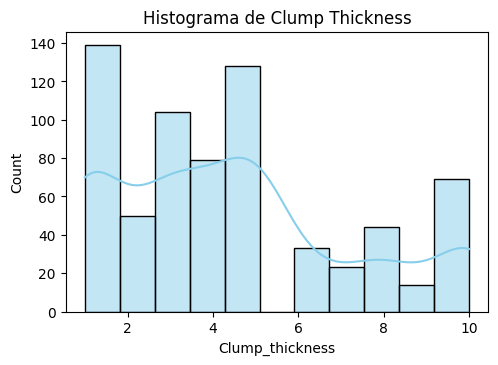

In [34]:
# Histograma de algunas variables
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
sns.histplot(df['Clump_thickness'], kde=True, color='skyblue')
plt.title('Histograma de Clump Thickness')

Text(0.5, 1.0, 'Gráfico de Densidad de Uniformity of Cell Size')

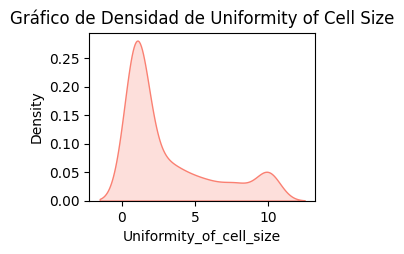

In [38]:
# Gráfico de densidad de otra variable
plt.subplot(2, 2, 2)
sns.kdeplot(df['Uniformity_of_cell_size'], fill=True, color='salmon')
plt.title('Gráfico de Densidad de Uniformity of Cell Size')

Text(0.5, 1.0, 'Boxplot de Bland Chromatin por Clase')

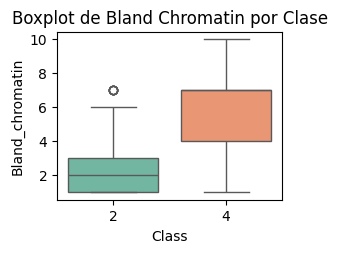

In [39]:
# Boxplot de una variable
plt.subplot(2, 2, 3)
sns.boxplot(x='Class', y='Bland_chromatin', hue='Class', data=df, palette='Set2', legend=False)
plt.title('Boxplot de Bland Chromatin por Clase')

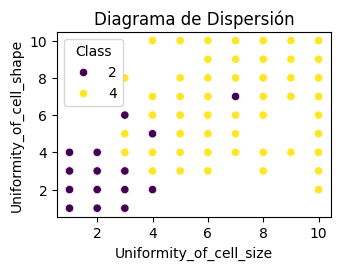

In [37]:
# Diagrama de dispersión entre dos variables
plt.subplot(2, 2, 4)
sns.scatterplot(x='Uniformity_of_cell_size', y='Uniformity_of_cell_shape', data=df, hue='Class', palette='viridis')
plt.title('Diagrama de Dispersión')

plt.tight_layout()
plt.show()

## **c. Utilice la librería ‘Scikit-learn’ para separar la información en datos de entrenamiento y prueba. Además, implemente un modelo k-NN con dicha información, realice pronósticos y mida la precisión para los datos de entrenamiento y prueba.**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [22]:
# Información en datos de entrenamiento y prueba
X = df.drop(['Sample_code_number', 'Class'], axis=1)  # Variables predictoras
y = df['Class']  # Variable objetivo

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Implementar un modelo k-NN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [40]:
# Realizar predicciones y medir precisión
y_pred_train = knn_model.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)

y_pred_test = knn_model.predict(X_test)
accuracy_test = accuracy_score(y_test, y_pred_test)

print(f'Precisión en datos de entrenamiento: {accuracy_train:.2f}')
print(f'Precisión en datos de prueba: {accuracy_test:.2f}')

Precisión en datos de entrenamiento: 0.97
Precisión en datos de prueba: 0.95
